# Reliance Stock Price Prediction using Machine Learning

### Author: Vishnu Vardhan

This notebook demonstrates a machine learning approach to predict the next day's stock closing price using historical stock data.

The goal is to analyze trends and apply predictive modeling using technical indicators.

## Problem Statement

Stock markets are highly dynamic and influenced by numerous factors.  
The objective of this project is to build a machine learning model that predicts the **next day's closing price** based on historical stock data.

This helps in understanding market trends and making data-driven insights.

## Dataset

- Source: Yahoo Finance (via `yfinance`)
- Time Range: January 2016 --- January 2026
- Stocks: Top companies from NIFTY 50

### Data Includes:
- Open
- High
- Low
- Close
- Volume

For this notebook, we demonstrate using a single stock (RELIANCE.NS).

## Import Libraries

We use standard Python libraries for:
- Data manipulation → pandas
- Visualization → matplotlib
- Machine Learning → scikit-learn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

## Load Data

We load preprocessed stock data which already includes engineered features such as moving averages and returns.

This keeps the notebook focused on modeling and analysis.

## Data Preview

Let’s inspect the first few rows of the dataset to understand its structure and available features.

In [2]:
file_path = "../data/processed/RELIANCE.NS.csv"
df = pd.read_csv(file_path)

df.head()

,Date,Open,High,Low,Close,Volume,Prev_Close,MA5,MA10,MA50,Return,Target
0,2016-03-14,220.822585,222.404376,219.489988,220.963440,11880095.0,219.825836,221.654648,218.491066,215.516863,0.005175,221.125961
1,2016-03-15,221.884348,222.718586,219.955872,221.125961,10487788.0,220.963440,221.372961,219.657910,215.539181,0.000736,221.396790
2,2016-03-16,221.234281,222.274363,217.864856,221.396790,11064129.0,221.125961,220.508392,220.534396,215.653807,0.001225,222.629578
3,2016-03-17,225.039942,227.209262,221.753079,222.629578,16832997.0,221.396790,221.188321,221.096458,215.750401,0.005568,225.083771
4,2016-03-18,223.122612,225.730182,222.563848,225.083771,14030979.0,222.629578,222.239908,221.658005,215.778853,0.011024,227.296890


## Stock Price Trend

We visualize the closing price over time to understand:
- Overall trend
- Volatility
- Market behavior

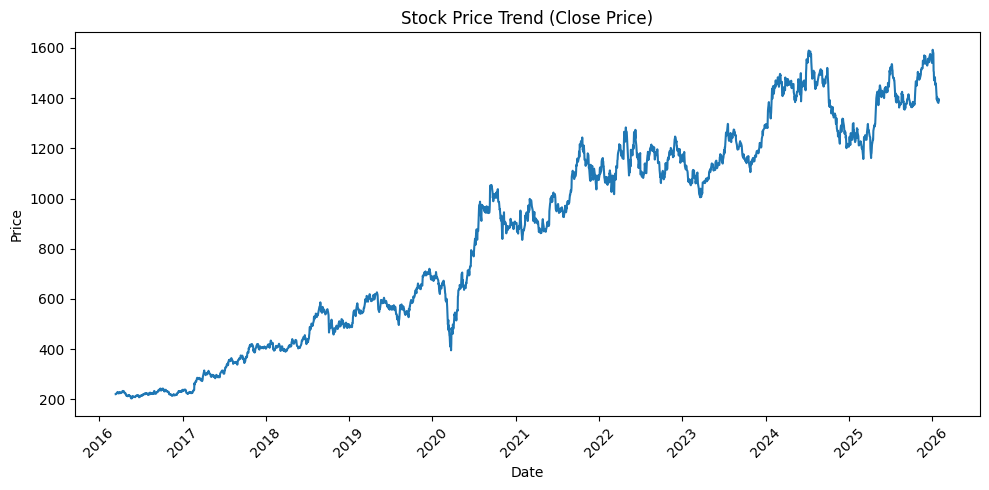

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])

plt.title("Stock Price Trend (Close Price)")
plt.xlabel("Date")
plt.ylabel("Price")

# Format x-axis (KEY FIX)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Feature Engineering

The following features are used for prediction:

- **Previous Close** → Price from the previous day  
- **MA5** → 5-day moving average  
- **MA10** → 10-day moving average  
- **MA50** → 50-day moving average  
- **Return** → Daily percentage change  

### Why these features?

These are commonly used technical indicators that help capture short-term and long-term trends in stock prices.

In [4]:
df[['Prev_Close', 'MA5', 'MA10', 'MA50', 'Return']].head()

,Prev_Close,MA5,MA10,MA50,Return
0,219.825836,221.654648,218.491066,215.516863,0.005175
1,220.963440,221.372961,219.657910,215.539181,0.000736
2,221.125961,220.508392,220.534396,215.653807,0.001225
3,221.396790,221.188321,221.096458,215.750401,0.005568
4,222.629578,222.239908,221.658005,215.778853,0.011024


## Train-Test Split

Since stock data is time-series, we **do not shuffle** the data.

Instead:
- First 80% → Training data  
- Last 20% → Testing data  

This ensures the model learns from past data and predicts future values realistically.

In [5]:
features = ['Prev_Close', 'MA5', 'MA10', 'MA50', 'Return']
target = 'Target'

X = df[features]
y = df[target]

split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

dates_test = df['Date'][split_index:]

## Model Selection

 - We use the **Random Forest Regressor** for prediction.

### Why Random Forest?

- Handles non-linear relationships well  
- Robust to noise  
- Requires minimal tuning  
- Performs better than simple linear models  

It is a strong baseline model for regression problems.

## Model Training

The model is trained using historical data and the selected features.

It learns patterns and relationships between input features and stock prices.

In [6]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Making Predictions

After training, the model is used to predict stock prices on unseen test data.

These predictions are compared against actual values.

In [7]:
predictions = model.predict(X_test)

## Model Evaluation

We evaluate the model using:

- **MAE (Mean Absolute Error)** → Average error magnitude  
- **RMSE (Root Mean Squared Error)** → Penalizes large errors  

Lower values indicate better model performance.

In [8]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 46.55
RMSE: 59.16


## Actual vs Predicted Prices

We compare actual stock prices with predicted values.

This helps us understand:
- How well the model captures trends  
- Where it deviates  

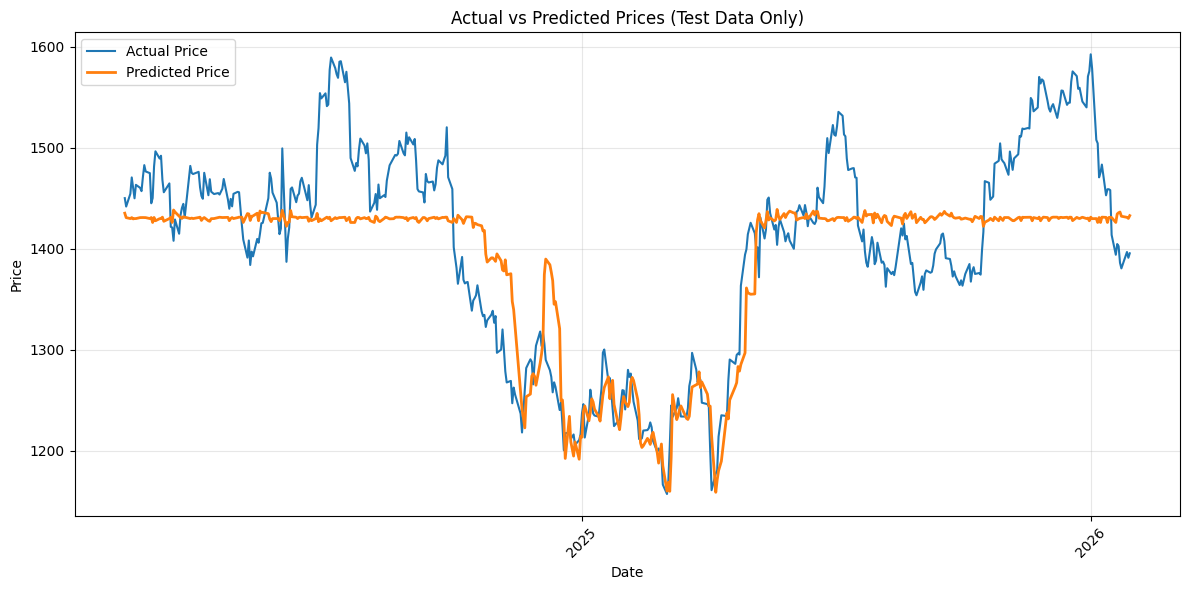

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Convert test dates
dates_test = pd.to_datetime(dates_test)

plt.figure(figsize=(12,6))

# Plot only test actual values
plt.plot(dates_test, y_test, label="Actual Price")

# Plot predictions
plt.plot(dates_test, predictions, label="Predicted Price", linewidth=2)

plt.title("Actual vs Predicted Prices (Test Data Only)")
plt.xlabel("Date")
plt.ylabel("Price")

# 2-year interval (still works fine for shorter range)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## Conclusion

- The model successfully captures general trends in stock prices  
- It performs reasonably well on unseen data  
- However, it cannot predict exact prices due to market volatility  

### Key Insight:
Stock prices are influenced by external factors such as:
- News
- Economic conditions
- Global events

Hence, predictions should be interpreted as trends, not exact values.

## Future Improvements

- Use Deep Learning models (LSTM, RNN)  
- Include external data (news sentiment, macroeconomic indicators)  
- Hyperparameter tuning  
- Build a real-time prediction system  